# Comparación de Modelos

## IMPORTACIÓN DE LIBRERÍAS

In [21]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## CARGA DE DATOS

In [22]:
df = pd.read_csv(r"C:\Users\Daniel Herrera\Documents\Personal\MCD\Tesis\Datos Tesis\Data_Crimes_2001.csv")

## División Train-Test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Preprocesamiento

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

## Definición de modelos

In [29]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=None  # LR no usa n_jobs en todas las versiones
    ),
    
    "DecisionTree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=50,
        max_depth=15,
        min_samples_leaf=50,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1  # 🔥 Usa todos los núcleos
    )
}

## Entrenamiento y Evaluación con Medición de Tiempo

In [36]:
import time

trained_models = {}

for name, model in models.items():
    
    print(f"\nEntrenando {name}...")
    
    start_time = time.time()  # 🔥 reinicia aquí
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    trained_models[name] = pipeline
    
    print(f"{name} terminó en {training_time:.2f} segundos")


Entrenando LogisticRegression...
LogisticRegression terminó en 1.66 segundos

Entrenando DecisionTree...
DecisionTree terminó en 2.66 segundos

Entrenando RandomForest...
RandomForest terminó en 9.67 segundos


## Evaluación comparativa de modelos entrenados

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results_list = []

for name, pipeline in trained_models.items():
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }
    
    results_list.append(results)

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,RandomForest,0.846540,0.868133,0.559647,0.680564,0.832215
0,LogisticRegression,0.838857,0.816344,0.578480,0.677130,0.826219
1,DecisionTree,0.839468,0.847017,0.549714,0.666724,0.797837


## Curvas ROC comparativas

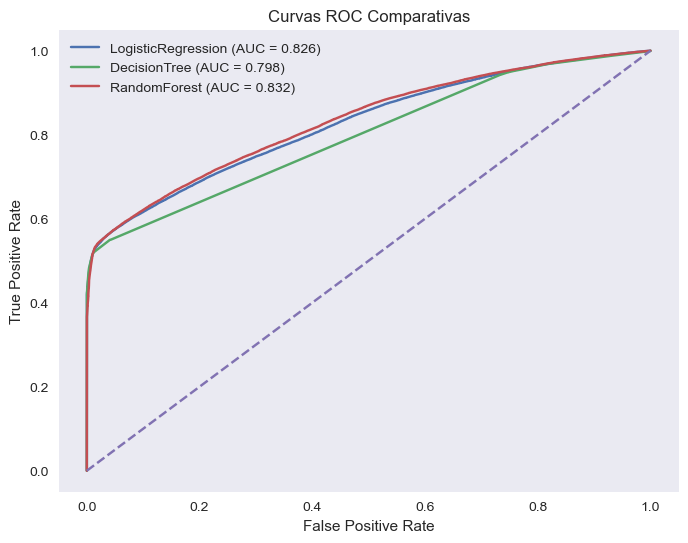

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, pipeline in trained_models.items():
    y_prob = pipeline.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Comparativas")
plt.legend()
plt.grid()
plt.show()

## Matriz de confusión

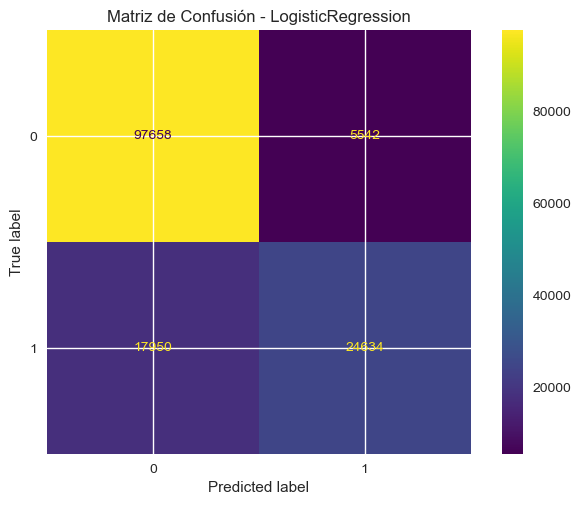

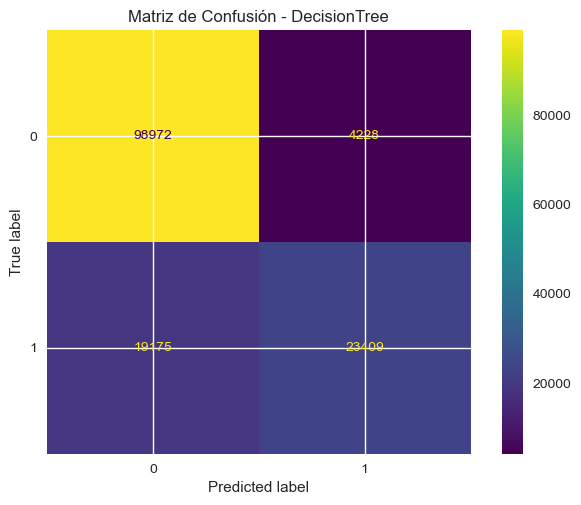

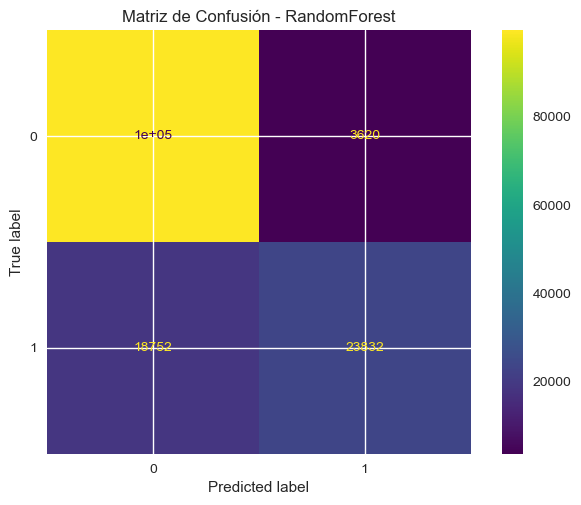

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()

## Ajuste de parámetros para regresión logística

In [41]:
import numpy as np
from sklearn.metrics import f1_score

pipeline = trained_models["LogisticRegression"]
y_prob = pipeline.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_adj = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_adj))

best_threshold = thresholds[np.argmax(f1_scores)]

print("Mejor threshold:", best_threshold)
print("Mejor F1:", max(f1_scores))

Mejor threshold: 0.5599999999999997
Mejor F1: 0.680463768115942


## Gráfica de mejor umbral y F1

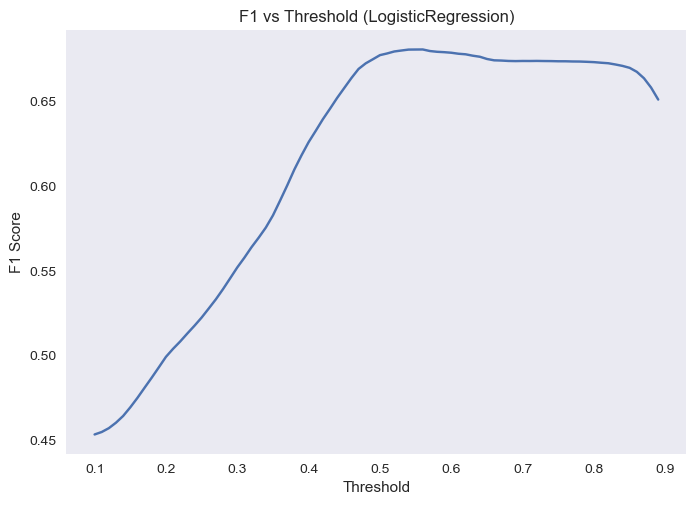

In [42]:
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold (LogisticRegression)")
plt.grid()
plt.show()

## Análisis de características de RandomForest

In [44]:
rf_pipeline = trained_models["RandomForest"]

ohe = rf_pipeline.named_steps['preprocess'].named_transformers_['cat']

feature_names = ohe.get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feat_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
)

feat_importance_df.head(15)

,Feature,Importance
17,Primary Type_NARCOTICS,0.494481
5,Primary Type_CRIMINAL DAMAGE,0.092371
7,Primary Type_CRIMINAL TRESPASS,0.067470
29,Primary Type_THEFT,0.056908
3,Primary Type_BURGLARY,0.049474
22,Primary Type_PROSTITUTION,0.043485
16,Primary Type_MOTOR VEHICLE THEFT,0.025351
30,Primary Type_WEAPONS VIOLATION,0.024489
2,Primary Type_BATTERY,0.022398
26,Primary Type_ROBBERY,0.018003


## Gráfico "Variables Más Importantes (RandomForest)"

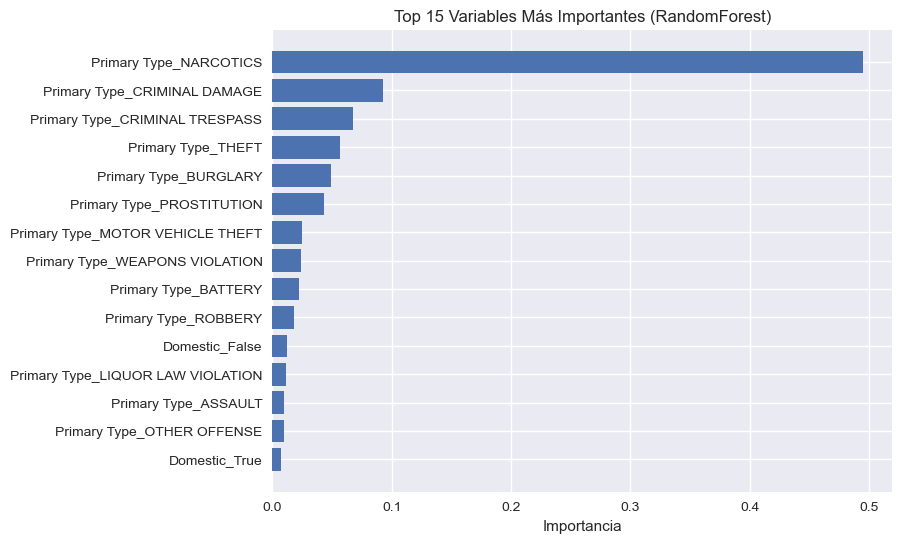

In [45]:
plt.figure(figsize=(8,6))
plt.barh(
    feat_importance_df.head(15)["Feature"][::-1],
    feat_importance_df.head(15)["Importance"][::-1]
)
plt.title("Top 15 Variables Más Importantes (RandomForest)")
plt.xlabel("Importancia")
plt.show()

## Justificación del modelo seleccionado

Aunque el modelo RandomForest presentó un desempeño ligeramente superior en términos de ROC-AUC, la diferencia fue marginal.

La regresión logística ofrece:

- Mayor eficiencia computacional
- Mejor interpretabilidad
- Mayor estabilidad
- Desempeño competitivo

El ajuste del umbral a 0.56 permitió optimizar el equilibrio entre precisión y recall, maximizando el F1-score.

Por estas razones, se selecciona la regresión logística como modelo final.